# Lab 02 - Phan tich kinh te WDI

**Phu trach:** Le Lam Tri Duc - 23120237

Notebook nay loc va lam sach nhom chi so kinh te tu World Development Indicators, xuat `data_output/wdi_economy.csv`, va chuan bi cac bieu do phan tich de dua vao Tableau/bao cao.

## Cau hoi phan tich

- Xu huong tang truong kinh te cua cac quoc gia/khu vuc giai doan 2000-2023 nhu the nao?
- GDP binh quan dau nguoi co moi quan he gi voi ty le ngheo?
- Cac cu soc nam 2008 va giai doan COVID-19 co the hien tren GDP growth hay khong?

## Indicators su dung

| Indicator code | Cot output | Y nghia |
|---|---|---|
| `NY.GDP.MKTP.CD` | `GDP_current_USD` | Quy mo GDP theo USD hien hanh |
| `NY.GDP.PCAP.CD` | `GDP_per_capita_current_USD` | Muc thu nhap/qui mo kinh te binh quan dau nguoi |
| `NY.GDP.MKTP.KD.ZG` | `GDP_growth_annual_pct` | Toc do tang truong GDP hang nam |
| `SI.POV.DDAY` | `Poverty_headcount_3usd_2021PPP_pct` | Ty le dan so song duoi nguong 3 USD/ngay theo PPP 2021 |

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# Optional visualization dependencies for local rerun.
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "WDIEXCEL.xlsx").exists() and (ROOT.parent / "WDIEXCEL.xlsx").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data_output" / "wdi_economy.csv"
df = pd.read_csv(DATA_PATH)
df.head()

## Ket qua tien xu ly

- So dong trong `wdi_economy.csv`: **5053**
- So quoc gia/vung lanh tho that co it nhat mot chi so kinh te: **214**
- Giai doan: **2000-2023**
- Quy uoc missing data: noi suy tuyen tinh neu khoang trong noi bo <= 2 nam; loai cap country-indicator neu khoang trong noi bo > 2 nam; khong extrapolate dau/cuoi chuoi.

## Bieu do 1 - Xu huong GDP per capita

Bieu do dung de so sanh muc GDP binh quan dau nguoi cua mot so quoc gia dai dien. Khi dua sang Tableau, dung line chart voi filter Country/Region.

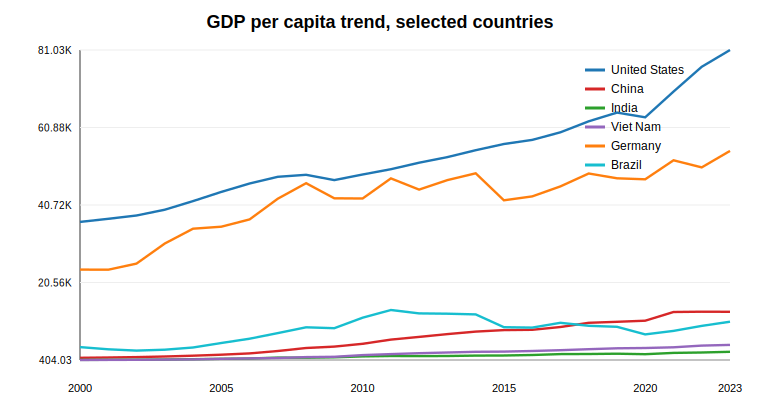

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_economy.csv


## Bieu do 2 - Tang truong GDP theo khu vuc

Bieu do thanh cho thay khac biet ve tang truong trung binh giua cac khu vuc trong nam gan nhat co du lieu.

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_economy.csv


## Bieu do 3 - GDP per capita va ty le ngheo

Scatter plot kiem tra moi quan he giua GDP per capita va poverty headcount. Truc X nen dung log scale de tranh cac nuoc thu nhap cao lam nen bieu do.

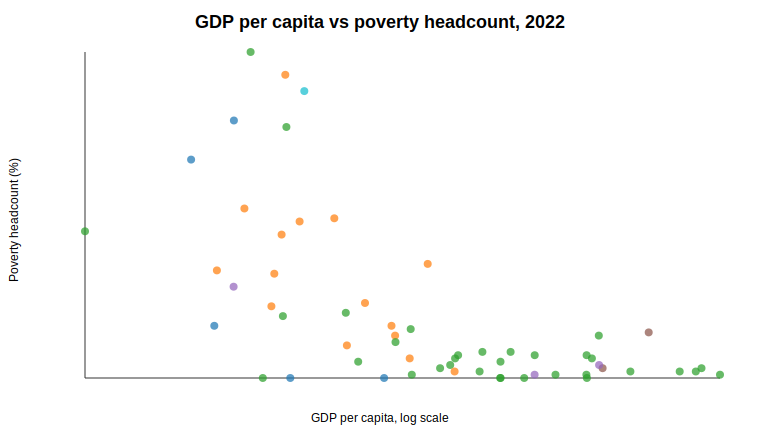

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_economy.csv


## Bieu do 4 - Phan bo GDP per capita theo khu vuc

Notebook tao tile choropleth theo khu vuc de xem nhanh phan bo GDP per capita. Khi lam san pham cuoi cung tren Tableau, thay bang choropleth map theo `Country_Name` hoac `Country_Code`.

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_economy.csv


## Code ve lai bieu do bang matplotlib

Cell nay dung khi mo notebook trong moi truong Jupyter co `matplotlib`. Cac bieu do SVG o tren da duoc tao san tu file CSV hien tai.

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

focus_countries = ["United States", "China", "India", "Viet Nam", "Germany", "Brazil"]
fig, ax = plt.subplots(figsize=(10, 5))
for country in focus_countries:
    sub = df[df["Country_Name"].eq(country)]
    ax.plot(sub["Year"], sub["GDP_per_capita_current_USD"], marker="o", linewidth=2, label=country)
ax.set_title("GDP per capita trend, selected countries")
ax.set_xlabel("Year")
ax.set_ylabel("Current US$")
ax.legend()
plt.show()

latest = df[df["Year"].eq(2023)]
region_growth = latest.groupby("Region", as_index=False)["GDP_growth_annual_pct"].mean().sort_values("GDP_growth_annual_pct", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(region_growth["Region"], region_growth["GDP_growth_annual_pct"], color="#3a7ca5")
ax.invert_yaxis()
ax.set_title("Average GDP growth by region, 2023")
ax.set_xlabel("Annual growth (%)")
plt.show()

scatter = df[df["Year"].eq(2022)].dropna(subset=["GDP_per_capita_current_USD", "Poverty_headcount_3usd_2021PPP_pct"])
fig, ax = plt.subplots(figsize=(9, 6))
for region, sub in scatter.groupby("Region"):
    ax.scatter(sub["GDP_per_capita_current_USD"], sub["Poverty_headcount_3usd_2021PPP_pct"], s=35, alpha=0.75, label=region)
ax.set_xscale("log")
ax.set_title("GDP per capita vs poverty headcount, 2022")
ax.set_xlabel("GDP per capita, current US$ (log scale)")
ax.set_ylabel("Poverty headcount at $3.00/day (%)")
ax.legend(bbox_to_anchor=(1.03, 1), loc="upper left")
plt.show()

## Goi y worksheet Tableau

1. **Line chart:** `Year` tren Columns, `GDP_per_capita_current_USD` tren Rows, `Country_Name` tren Color, filter `Region`/`Income_Group`.
2. **Bar chart:** `Region` tren Rows, AVG(`GDP_growth_annual_pct`) tren Columns, filter `Year`.
3. **Scatter plot:** `GDP_per_capita_current_USD` tren Columns, `Poverty_headcount_3usd_2021PPP_pct` tren Rows, `Region` tren Color, `Country_Name` tren Detail.
4. **Map:** `Country_Name`/`Country_Code` lam geographic role, color theo `GDP_per_capita_current_USD`, filter `Year`.

## Nhan xet so bo

- GDP per capita tang manh o nhieu quoc gia chau A trong giai doan 2000-2023, nhung muc tuyet doi van chen lech lon so voi nhom thu nhap cao.
- GDP growth co bien dong ro quanh cac nam khung hoang tai chinh 2008-2009 va COVID-19 2020.
- Scatter plot ky vong the hien quan he nghich: GDP per capita cang cao thi poverty headcount cang thap, du van co ngoai lai do bat binh dang va khac biet co cau kinh te.